<a href="https://colab.research.google.com/github/MateusAFalcao/RNA-e-Deep-Learning---CESAR-School-2025.02/blob/main/C%C3%B3pia_de_3_2_LogisticRegressionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [2]:
! git clone https://github.com/vcasadei/MNIST.git

fatal: destination path 'MNIST' already exists and is not an empty directory.


In [3]:
!ls MNIST

processed  raw


In [4]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [5]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [6]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

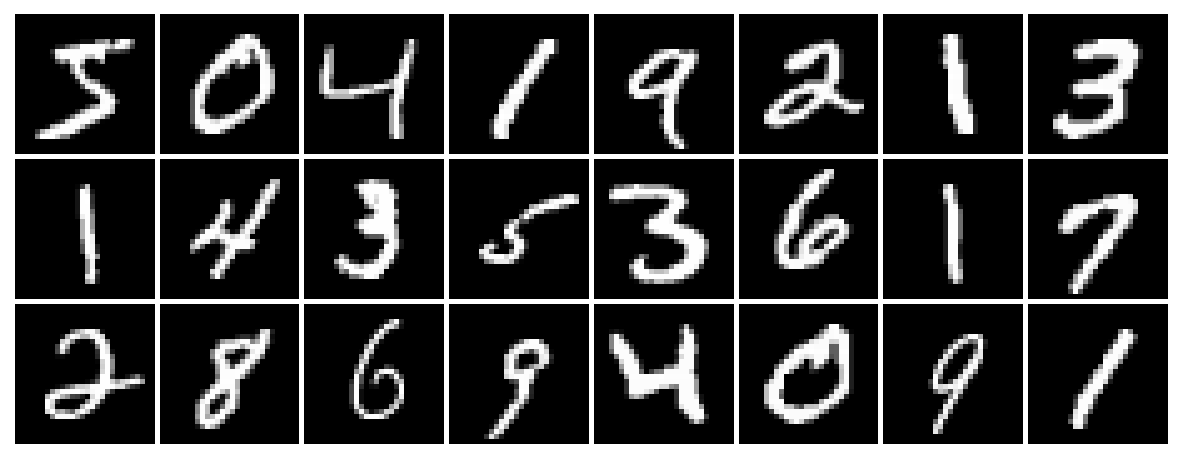

In [7]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


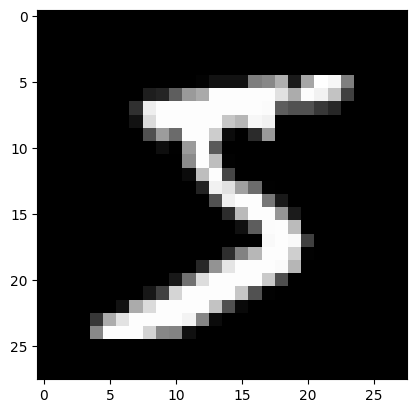

In [8]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [9]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [10]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[ 0.0613, -0.0645,  0.1877, -0.3326,  0.0972,  0.0117,  0.0110,  0.2458,
         -0.1481,  0.0649],
        [-0.3119, -0.3614,  0.3017,  0.1398, -0.2393,  0.2075,  0.1308,  0.0389,
         -0.1768,  0.3736],
        [-0.1715, -0.2019, -0.0532,  0.0202,  0.1332,  0.2243, -0.1631, -0.1269,
         -0.3072,  0.0827],
        [-0.0714, -0.0649,  0.1692, -0.0878, -0.3481,  0.2544,  0.0806,  0.3347,
         -0.0895,  0.1864],
        [ 0.1351, -0.5107,  0.1171, -0.4281,  0.0598,  0.2113, -0.0328, -0.0108,
         -0.2612,  0.3332]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [11]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [12]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [13]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

    #Resposta do exercício 2: Visualizar os valores dos gradientes da classe do dígito 4
    pesos_ultima_camada = list(model.parameters())[-2]

    if pesos_ultima_camada.grad is not None:
        gradientes_digito_4 = pesos_ultima_camada.grad[4]
        print(f'---> Gradientes para o dígito 4 na época {i+1}:\n{gradientes_digito_4}\n')

A saída de streaming foi truncada nas últimas 5000 linhas.
         7.4971e-06,  1.3815e-05,  8.7571e-05,  1.7985e-04,  2.5914e-04,
         4.3315e-04,  2.5239e-04,  3.9844e-04,  2.4459e-04,  1.3447e-04,
         9.7294e-04,  1.6601e-04, -7.3451e-04,  5.4782e-04, -2.3878e-04,
         7.6562e-05, -5.5875e-04,  1.5998e-04, -6.0508e-06, -4.2999e-04,
        -5.5190e-05,  9.7779e-06,  4.4727e-07,  1.0223e-07,  2.8067e-07,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  3.0026e-08,  4.3636e-06,
         3.1644e-05,  1.0880e-04,  2.3925e-04,  6.4018e-05,  9.1232e-05,
         2.4418e-04, -1.3522e-04,  1.0244e-04,  1.1144e-03, -2.4400e-04,
         6.6554e-05,  2.7376e-04, -4.0970e-04, -1.4209e-04, -8.0168e-04,
         3.6558e-06, -1.0168e-04, -3.0127e-04, -8.4914e-05,  7.4453e-06,
         1.1138e-06,  5.6857e-08,  1.3022e-07,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  1.0679e-09,  1.3821e-05,  4.0199e-05,  8.3703e-05,
         9.6077e-05, -4.8229e-05,  6.6830e-06, -2.3681e-04, -3.46

In [14]:
print('Final loss:', loss.item())

Final loss: 0.26603296399116516


### Visualizando gráfico de perda durante o treinamento

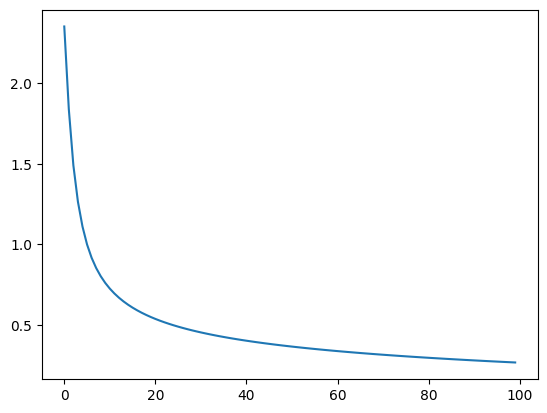

In [15]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

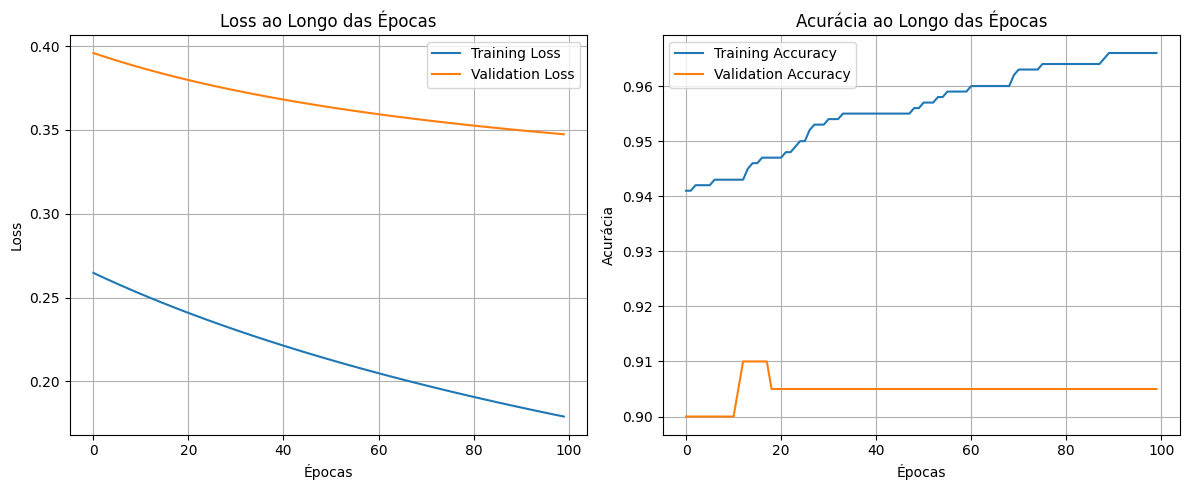

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [17]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.967


### Matriz de confusão com dados de treinamento e teste

In [18]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


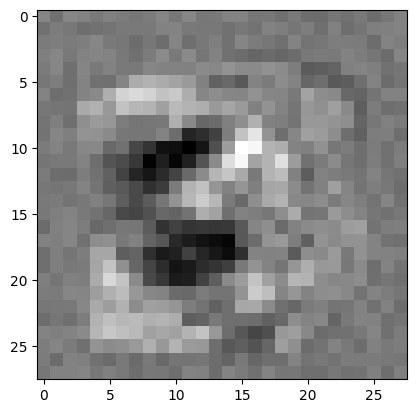

In [19]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

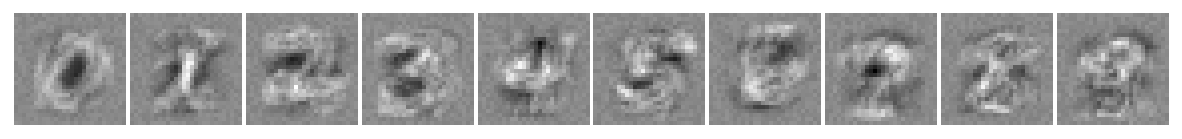

In [20]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

Resposta 1: Isso está sendo executado no segundo bloco de código de laço de treinamento.

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

Resposta 2: Alterei o bloco de código do laço de repetição que está acima no colab (deixei um comentário lá pra ter certeza)

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
    O shape é (N, 784).
2. Qual é o shape da saída da rede?
    O shape de saída é (N, 10).
3. Qual é o número total de parâmetros da rede, incluindo o bias?
    A rede possui 7850 parâmetros. São 784 entradas x 10 saídas + 10 do bias (7850).

# Aprendizados
